In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import generate_lorentz as gl
import generate_data as gd
import classify_data as cd
import os

/usr/local/lib/python3.7/dist-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/usr/local/lib/python3.7/dist-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/usr/local/lib/python3.7/dist-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/usr/local/lib/python3.7/dist-packages/tensorflow/python/framework/dtypes.py:519: FutureWarning: Passing (type, 1) or 

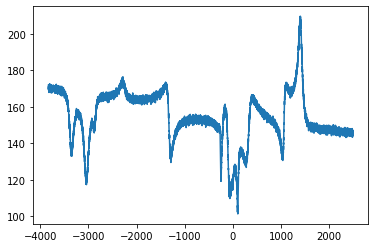

In [2]:
# Preview a sample of generated data
background_params, lorentz_params, f, v = gl.generate_data()
plt.plot(f, v)

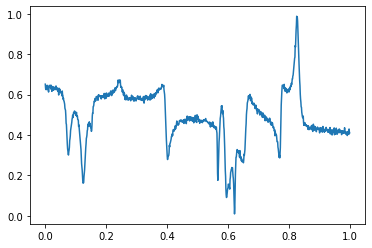

In [3]:
# Preview that sample, but normalized
f_norm = cd.normalize_1d(f)
v_norm = cd.normalize_1d(v)
plt.plot(f_norm, v_norm)

In [4]:
# Decide where to generate data and load it from
root = os.getcwd()
train_dir = os.path.join(root, 'generated_data_train')
test_dir = os.path.join(root, 'generated_data_test')

In [9]:
# Generate a testing data set and training data set
gd.generate_data_set(root, 'generated_data_train', include_noise=True, count=1000)
gd.generate_data_set(root, 'generated_data_test', include_noise=True, count=1000)

In [10]:
# Load those testing and training data sets
train_data_set = gd.load_data_set(train_dir)
test_data_set = gd.load_data_set(test_dir)

In [11]:
# Preprocess/normalize the data sets so the number of clusters can be detected
count_labels, count_data = cd.pre_process_for_counting(train_data_set)

In [12]:
# Set up the cluster counting model
cluster_count_model = keras.Sequential([
    keras.layers.Flatten(),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(32),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(128)
])

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [13]:
# Compile the cluster counting model
cluster_count_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [38]:
# Fit the cluster counting model
cluster_count_model.fit(count_data, count_labels, epochs=50)

Epoch 1/50
1000/1000 [==============================] - 1s 690us/sample - loss: 162845.4790 - acc: 0.9240
Epoch 2/50
1000/1000 [==============================] - 1s 594us/sample - loss: 86921.8973 - acc: 0.9310
Epoch 3/50
1000/1000 [==============================] - 1s 581us/sample - loss: 50192.5612 - acc: 0.9300
Epoch 4/50
1000/1000 [==============================] - 1s 693us/sample - loss: 101990.0955 - acc: 0.9200
Epoch 5/50
1000/1000 [==============================] - 1s 576us/sample - loss: 44197.4654 - acc: 0.9400
Epoch 6/50
1000/1000 [==============================] - 1s 627us/sample - loss: 53521.1437 - acc: 0.9270
Epoch 7/50
1000/1000 [==============================] - 1s 645us/sample - loss: 50995.4650 - acc: 0.9430
Epoch 8/50
1000/1000 [==============================] - 1s 578us/sample - loss: 48999.5077 - acc: 0.9210
Epoch 9/50
1000/1000 [==============================] - 1s 692us/sample - loss: 76775.5747 - acc: 0.9210
Epoch 10/50
1000/1000 [==============================

In [15]:
# Preprocess/normalize the data sets so the class of each clusters can be detected
class_labels, class_data = cd.pre_process_for_classifying(train_data_set)

In [19]:
# Set up the cluster classifying model
cluster_class_model = keras.Sequential([
    keras.layers.Flatten(),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(32),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(1024),
    keras.layers.Dense(128)
])

In [20]:
# Compile the cluster classifying model
cluster_class_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [21]:
# Fit the cluster classifying model
cluster_class_model.fit(class_data, class_labels, epochs=30)

Epoch 1/30
5304/5304 [==============================] - 3s 626us/sample - loss: 5.6993 - acc: 0.5756
Epoch 2/30
5304/5304 [==============================] - 3s 603us/sample - loss: 1.0403 - acc: 0.6723
Epoch 3/30
5304/5304 [==============================] - 3s 606us/sample - loss: 1.0192 - acc: 0.6729
Epoch 4/30
5304/5304 [==============================] - 3s 603us/sample - loss: 1.0121 - acc: 0.6727
Epoch 5/30
5304/5304 [==============================] - 3s 607us/sample - loss: 1.0095 - acc: 0.6729
Epoch 6/30
5304/5304 [==============================] - 3s 610us/sample - loss: 0.9999 - acc: 0.6729
Epoch 7/30
5304/5304 [==============================] - 3s 618us/sample - loss: 1.0071 - acc: 0.6723
Epoch 8/30
5304/5304 [==============================] - 4s 703us/sample - loss: 1.0029 - acc: 0.6729
Epoch 9/30
5304/5304 [==============================] - 4s 666us/sample - loss: 1.0111 - acc: 0.6718
Epoch 10/30
5304/5304 [==============================] - 4s 743us/sample - loss: 1.0010 - a

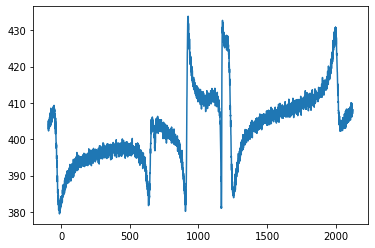

In [33]:
# Preview a sample of generated data
background_params, lorentz_params, f, v = gl.generate_data()
plt.plot(f, v)

In [34]:
# Preview the current Lorentzian separations
da = cd.merge_data(f, v)
frl = cd.disect_lorentz_params_array(lorentz_params)[1]
t = cd.partition_data_2d(da, frl, lorentz_params)[0]
print(cd.partition_data_2d(da, frl, lorentz_params)[1])
print(cd.partition_data_2d(da, frl, lorentz_params)[1].shape[0])
x = np.linspace(0,1,1024)

[[1.]
 [2.]
 [1.]
 [2.]
 [1.]]
5


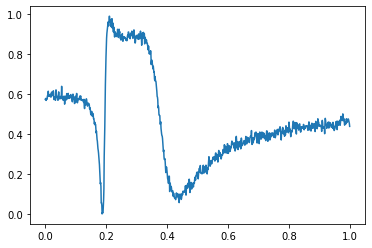

In [36]:
plt.plot(x, t[3])